In [1]:
import pandas as pd

data = pd.DataFrame({
    "Study_Hours": [2, 4, 6, 8],
    "Marks": [40, 50, 65, 80]
})

print(data)

   Study_Hours  Marks
0            2     40
1            4     50
2            6     65
3            8     80


In [2]:
print(data.head())
print(data.shape)
print(data.columns)

   Study_Hours  Marks
0            2     40
1            4     50
2            6     65
3            8     80
(4, 2)
Index(['Study_Hours', 'Marks'], dtype='object')


In [5]:
import pandas as pd

data = pd.read_csv("student-mat.csv", sep=';')

print(data.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [6]:
print(data.shape)
print(data.columns)
print(data.describe())

(395, 33)
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
              age        Medu        Fedu  traveltime   studytime    failures  \
count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000

In [7]:
data = data[['studytime', 'absences', 'G1', 'G2', 'G3']]

print(data.head())

   studytime  absences  G1  G2  G3
0          2         6   5   6   6
1          2         4   5   5   6
2          2        10   7   8  10
3          3         2  15  14  15
4          2         4   6  10  10


In [8]:
X = data[['studytime', 'absences', 'G1', 'G2']]
y = data['G3']

print(X.head())
print(y.head())

   studytime  absences  G1  G2
0          2         6   5   6
1          2         4   5   5
2          2        10   7   8
3          3         2  15  14
4          2         4   6  10
0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape)
print(X_test.shape)

(316, 4)
(79, 4)


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [11]:
predictions = model.predict(X_test)

print(predictions[:5])
print(y_test[:5])

[ 8.87335715 15.87171694  9.38705127 -1.0289412   6.55278004]
95     10
14     16
341     0
242     0
100     5
Name: G3, dtype: int64


In [12]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", error)

Mean Absolute Error: 1.3076404150809722


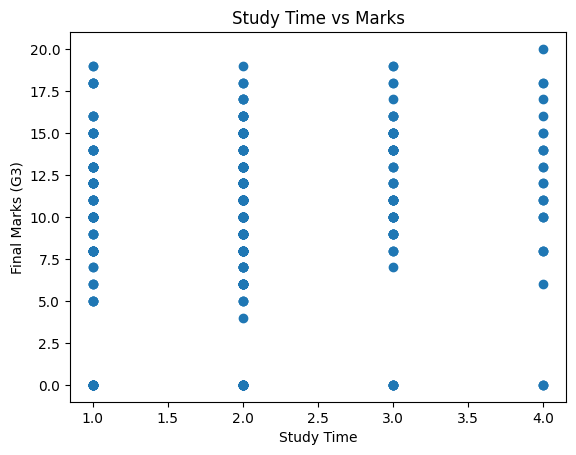

In [13]:
import matplotlib.pyplot as plt

plt.scatter(data['studytime'], data['G3'])

plt.xlabel("Study Time")
plt.ylabel("Final Marks (G3)")
plt.title("Study Time vs Marks")

plt.show()

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor()

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error

dt_error = mean_absolute_error(y_test, dt_predictions)

print("Decision Tree Error:", dt_error)

Decision Tree Error: 1.6308016877637133
